# 04 — ML Classification Models (scikit-learn baseline)

A fast, lightweight comparison of **3 classification models** on the event-level features, using scikit-learn — useful as a quick baseline before the full PySpark MLlib pipeline.


In [1]:
import os, sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['HADOOP_HOME'] = r'C:\Hadoop'

In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = pd.read_csv("data/event_level_features.csv").dropna(
    subset=["hour_of_day", "prev_headway_sec", "is_bunching"]
)

X = df[["hour_of_day", "prev_headway_sec"]]
y = df["is_bunching"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None)
print("Train:", len(X_train), "| Test:", len(X_test))


Train: 259 | Test: 65


In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    preds = model.predict(X_test)

    try:
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else float("nan")
    except Exception:
        auc = float("nan")

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": auc,
        "train_time_sec": train_time,
    })

results_pdf = pd.DataFrame(results)
results_pdf["f1_per_sec"] = results_pdf["f1"] / results_pdf["train_time_sec"]
results_pdf


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,f1_per_sec
0,LogisticRegression,0.615385,0.200000,0.105263,0.137931,0.790618,0.166783,0.827008
1,RandomForest,0.861538,0.812500,0.684211,0.742857,0.856407,0.270355,2.747705
2,GradientBoosting,0.876923,0.866667,0.684211,0.764706,0.871281,0.193875,3.944323


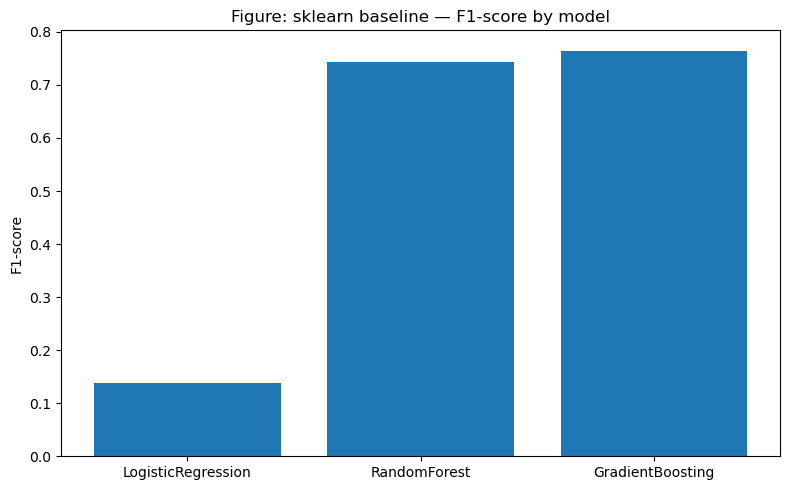

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(results_pdf["model"], results_pdf["f1"])
ax.set_title("Figure: sklearn baseline — F1-score by model")
ax.set_ylabel("F1-score")
plt.tight_layout()
plt.savefig("figure_sklearn_baseline_f1.png", dpi=150)
plt.show()

results_pdf.to_csv("data/sklearn_model_results.csv", index=False)
